# **Mathématiques pour Machine Learning Project 2026-2027**

## _Requirements_

Over the course of this project, we will handle images, matrices, and graphs to understand oru results. For this purpose, it is mandatory to run the following cell, in order to install all the libraries. <br>
Be aware that this operation can take a while.

In [27]:
# %pip install pillow
# %pip install numpy
# %pip install requests
# %pip install scikit-learn
# %pip install matplotlib

## _Imports_

In [28]:
import numpy as np
from PIL import Image
import requests
from io import BytesIO
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

## 1. The MNIST Database

### 1.1 Retrieving the dataset

Import of the files from the github (https://github.com/mbornet-hl/MNIST/tree/master/IMAGES/GROUPS), normalization.

In [29]:
cols, rows = 40, 25   # was (25, 40) before


file_path = "cleaned_mnist_filenames.txt"
with open(file_path, 'r') as file:
    content = file.read()
    filenames = [name.strip() for name in content.split(',') if name.strip()]

github_url = "https://github.com/mbornet-hl/MNIST/raw/master/IMAGES/GROUPS/"

x_list = []
y_list = []

for fname in filenames:
    label = int(fname.split('-')[1].split('_')[0])
    response = requests.get(github_url + fname)

    if response.status_code == 200:
        sheet = Image.open(BytesIO(response.content)).convert('L')
        cols, rows = 40, 25   # was (25, 40) before

        W, H = sheet.size     # 1920, 1080
        sheet_digit_w = W // cols   # 1920 // 40 = 48
        sheet_digit_h = H // rows   # 1080 // 25 = 43

        margin_x = (1920 - 40*28) // 2   # = 400px left margin
        margin_y = (1080 - 25*28) // 2   # = 190px top margin

        print(f"margin_x: {margin_x}, margin_y: {margin_y}")

        start_x, start_y = 300, 200
        end_x, end_y = 1730, 970

        cell_w = (end_x - start_x) / 40
        cell_h = (end_y - start_y) / 25

        for r in range(25):
            for c in range(40):
                # Calculate the four corners for this specific digit
                left   = start_x + (c * cell_w)
                top    = start_y + (r * cell_h)
                right  = left + cell_w
                bottom = top + cell_h

                # Crop the cell
                digit_crop = sheet.crop((left, top, right, bottom))

                # Resize to standard MNIST size (28x28)
                digit_crop = digit_crop.resize((28, 28), Image.Resampling.LANCZOS)

                # Convert to 0-1 range and INVERT
                # MNIST expects black background (0) and white drawing (1)
                vec = 1-(np.array(digit_crop).flatten() / 255.0)
                x_list.append(vec)
                y_list.append(label)

    else:
        print(f"Failed: {fname}")

X = np.array(x_list)
y = np.array(y_list)
print(X.shape)   # should be (63000, 784)
print(y.shape)   # should be (63000,)

margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400, margin_y: 190
margin_x: 400,

### 1.2 Dataset splitting

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
print(X_train[:5])
print(y_train[:5])
print(X_test[:5])
print(y_test[:5])

(42210, 784)
(42210,)
(20790, 784)
(20790,)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[6 8 8 1 2]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[8 0 7 6 3]


### 1.3 Classification Model

In [31]:
# =============================================================================
# 1. SOFTMAX
# =============================================================================
# For a score vector o of size 10:
#   P_k = e^{o_k} / sum_j e^{o_j}
#
# Numerical trick: subtract max(o) before exponentiating to avoid overflow.
# This doesn't change the result since:
#   e^{o_k} / sum e^{o_j} = e^{o_k - c} / sum e^{o_j - c}  for any c

def softmax(o):
    """
    Compute softmax probabilities.

    Args:
        o : np.ndarray of shape (n, 10) — score matrix (one row per sample)

    Returns:
        P : np.ndarray of shape (n, 10) — probability matrix
    """
    # Subtract max per row for numerical stability
    o_stable = o - np.max(o, axis=1, keepdims=True)
    exp_o = np.exp(o_stable)
    P = exp_o / np.sum(exp_o, axis=1, keepdims=True)
    return P

In [32]:
# =============================================================================
# 2. ONE-HOT ENCODING
# =============================================================================
# Converts a label vector y of shape (n,) with values in {0,...,9}
# into a matrix Y of shape (n, 10) where Y[i, y[i]] = 1, rest = 0.

def one_hot(y, num_classes=10):
    """
    Args:
        y           : np.ndarray of shape (n,) — integer labels
        num_classes : int

    Returns:
        Y : np.ndarray of shape (n, num_classes)
    """
    n = len(y)
    Y = np.zeros((n, num_classes))
    Y[np.arange(n), y] = 1
    return Y

In [33]:
# =============================================================================
# 3. CROSS-ENTROPY LOSS
# =============================================================================
# L = - (1/n) * sum_i sum_k  y_i^(k) * ln(P_k(x_i))
#
# Since y is one-hot, only the term k = y_i survives:
#   L = - (1/n) * sum_i ln(P_{y_i}(x_i))
#
# We clip P to avoid log(0)

def cross_entropy_loss(P, Y):
    """
    Args:
        P : np.ndarray of shape (n, 10) — predicted probabilities
        Y : np.ndarray of shape (n, 10) — one-hot true labels

    Returns:
        loss : float — scalar cross-entropy loss
    """
    n = P.shape[0]
    # Clip to avoid log(0)
    P_clipped = np.clip(P, 1e-12, 1.0)
    loss = 0

    for i in range(n):
        for k in range(10):
            loss += Y[i][k] * np.log(P_clipped[i][k])
            
    return loss*(-1/n)

In [34]:
# =============================================================================
# 4. FORWARD PASS
# =============================================================================
# Given weights A (10x784) and biases b (10,):
#   o = X @ A.T + b      shape: (n, 10)
#   P = softmax(o)       shape: (n, 10)

def forward(X, A, b):
    """
    Args:
        X : np.ndarray of shape (n, 784) — input data
        A : np.ndarray of shape (10, 784) — weight matrix
        b : np.ndarray of shape (10,) — bias vector

    Returns:
        o : np.ndarray of shape (n, 10) — scores (logits)
        P : np.ndarray of shape (n, 10) — probabilities
    """
    o = X @ A.T + b      # (n, 784) @ (784, 10) + (10,) = (n, 10)
    P = softmax(o)
    return o, P

In [35]:
# =============================================================================
# 5. GRADIENTS
# =============================================================================
# From the derivation:
#
#   dL/dA = (1/n) * (P - Y).T @ X       shape: (10, 784)
#   dL/db = (1/n) * sum_i (P - Y)_i     shape: (10,)
#
# where (P - Y) has shape (n, 10).

def compute_gradients(X, P, Y):
    """
    Args:
        X : np.ndarray of shape (n, 784)
        P : np.ndarray of shape (n, 10) — predicted probabilities
        Y : np.ndarray of shape (n, 10) — one-hot true labels

    Returns:
        dA : np.ndarray of shape (10, 784)
        db : np.ndarray of shape (10,)
    """
    n = X.shape[0]
    diff = P - Y                          # (n, 10)  — "prediction minus truth"
    dA = (diff.T @ X) / n                 # (10, n) @ (n, 784) = (10, 784)
    db = np.sum(diff, axis=0) / n         # (10,)
    return dA, db

In [36]:
# =============================================================================
# 6. GRADIENT DESCENT
# =============================================================================

def gradient_descent(X_train, y_train, learning_rate=0.1, n_epochs=100):
    """
    Train the linear model using full-batch gradient descent.

    Args:
        X_train       : np.ndarray of shape (n, 784)
        y_train       : np.ndarray of shape (n,) — integer labels
        learning_rate : float
        n_epochs      : int

    Returns:
        A      : np.ndarray of shape (10, 784) — trained weights
        b      : np.ndarray of shape (10,) — trained biases
        losses : list of float — loss at each epoch
    """
    n, d = X_train.shape     # n = nb samples, d = 784
    num_classes = 10

    # --- Initialization: small random weights, zero biases ---
    # We use small values to avoid saturation of softmax at the start
    rng = np.random.default_rng(seed=42)
    A = np.zeros((10,d))   # (10, 784)
    b = np.zeros(num_classes)                         # (10,)

    # One-hot encode labels once
    Y_train = one_hot(y_train, num_classes)           # (n, 10)

    losses = []

    for epoch in range(n_epochs):
        # --- Forward pass ---
        _, P = forward(X_train, A, b)

        # --- Loss ---
        loss = cross_entropy_loss(P, Y_train)
        losses.append(loss)

        # --- Gradients ---
        dA, db = compute_gradients(X_train, P, Y_train)

        # --- Parameter update ---
        A = A - learning_rate * dA
        b = b - learning_rate * db

        if epoch % 10 == 0:
            print(f"Epoch {epoch:4d} | Loss: {loss:.4f}")

    return A, b, losses

In [37]:
# =============================================================================
# 7. PREDICTION & ERROR RATE
# =============================================================================

def predict(X, A, b):
    """
    Returns predicted class for each sample.

    Args:
        X : np.ndarray of shape (n, 784)
        A : np.ndarray of shape (10, 784)
        b : np.ndarray of shape (10,)

    Returns:
        y_hat : np.ndarray of shape (n,) — predicted labels
    """
    _, P = forward(X, A, b)
    y_hat = np.argmax(P, axis=1)
    return y_hat


def error_rate(y_true, y_pred):
    """
    Returns the fraction of misclassified samples.
    """
    return np.mean(y_true != y_pred)

In [38]:
# =============================================================================
# 8. MAIN — plug in your X_train, X_test, y_train, y_test from your notebook
# =============================================================================

if __name__ == "__main__":
    # --- Load your data here ---
    # X_train, X_test, y_train, y_test are assumed to already be defined
    # (from your notebook's train_test_split)

    # --- Train ---
    from sklearn.preprocessing import LabelBinarizer
    lb = LabelBinarizer()
    Y_train = lb.fit_transform(y_train)   # (42210, 10)
    Y_test  = lb.transform(y_test)        # (20790, 10)
    
    A, b, losses = gradient_descent(
        X_train, y_train,
        learning_rate=0.01,
        n_epochs=30
    )

    # --- Evaluate ---
    y_pred_train = predict(X_train, A, b)
    y_pred_test  = predict(X_test,  A, b)

    print(f"\nError rate on TRAIN set : {error_rate(y_train, y_pred_train)*100:.2f}%")
    print(f"Error rate on TEST  set : {error_rate(y_test,  y_pred_test) *100:.2f}%")


Epoch    0 | Loss: 2.3026
Epoch   10 | Loss: 2.2471
Epoch   20 | Loss: 2.1947

Error rate on TRAIN set : 35.47%
Error rate on TEST  set : 35.57%


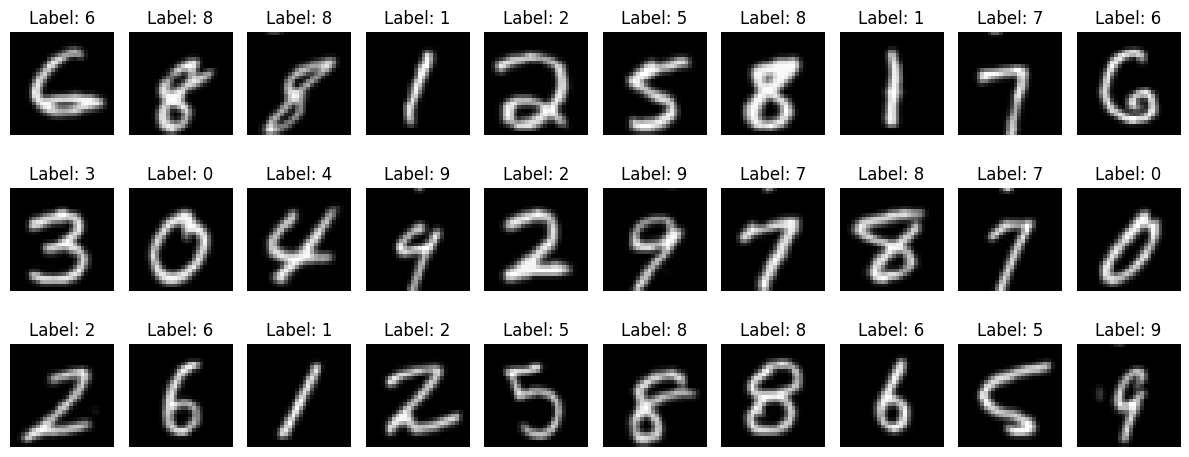

In [39]:
fig, axes = plt.subplots(3, 10, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

### 1.3. Multi-Layer Classification

In [40]:
def relu(x):
    return np.maximum(0, x)

def relu_diff(x):
    return (x > 0).astype(float)

def softmax(o):
    exp_o = np.exp(o - np.max(o))  # numerical stability
    return exp_o / np.sum(exp_o)

In [41]:
class Neuron:
    def __init__(self, input_size):
        # Parameters
        self.weights = np.random.randn(input_size) * 0.01
        self.bias = 0.0
        
        # Gradients (for backprop)
        self.dW = np.zeros_like(self.weights)
        self.db = 0.0

In [42]:
class Layer :
    def __init__(self, input_size, numberNeurons, activation="relu"):
        self.neurons = [Neuron(input_size) for _ in range(numberNeurons)]
        self.activation = activation
        
        # Stored values for backprop
        self.z = None
        self.o = None
        self.delta = None
        
        
    """
    in inputs: the layer of inputs. If it is a layer of neurons, we pass the values of the neurons 
    """
    def forward(self, inputs, is_output=False):
        o = []
        
        for neuron in self.neurons:
            o_i = np.dot(neuron.weights, inputs) + neuron.bias
            o.append(o_i)
        
        o = np.array(o)
        self.o = o
        
        # Activation
        if is_output:
            self.z = softmax(o)
        else:
            if self.activation == "relu":
                self.z = relu(o)
            else:
                raise ValueError("Unsupported activation")
        
        return self.z

In [43]:
def vect_of(y, num_classes=10):
    v = np.zeros(num_classes)
    v[y] = 1
    return v

def cross_entropy(y_hat, y):
    y_vec = vect_of(y)
    return -np.sum(y_vec * np.log(y_hat + 1e-15))  # avoid log(0)

In [44]:
def forward_network(x, layers):
    current = x
    
    for i, layer in enumerate(layers):
        o = []
        
        for neuron in layer.neurons:
            o_i = np.dot(neuron.weights, current) + neuron.bias
            o.append(o_i)
        
        o = np.array(o)
        layer.o = o  # store for backprop
        
        # activation
        if i == len(layers) - 1:
            # OUTPUT LAYER → softmax
            z = softmax(o)
        else:
            z = relu(o)
        
        layer.z = z  # store
        current = z
        
    return current  # final prediction

In [46]:
def backward_network(x, y, layers, lr):
    y_vec = vect_of(y)
    
    L = len(layers)
    
    # OUTPUT LAYER 
    last = layers[-1]
    delta = last.z - y_vec   # diff cross entropy / softmax
    
    last.delta = delta
    
    # gradients for last layer
    prev_z = layers[-2].z if L > 1 else x
    
    for i, neuron in enumerate(last.neurons):
        neuron.dW = delta[i] * prev_z
        neuron.db = delta[i]
    
    # HIDDEN LAYERS 
    for h in reversed(range(L - 1)):
        current = layers[h]
        next_layer = layers[h + 1]
        
        delta_new = []
        
        for i, neuron in enumerate(current.neurons):
            # sum over next layer
            s = 0
            for j, next_neuron in enumerate(next_layer.neurons):
                s += next_layer.delta[j] * next_neuron.weights[i]
            
            d = s * relu_diff(current.z[i])
            delta_new.append(d)
        
        delta_new = np.array(delta_new)
        current.delta = delta_new
        
        prev_z = layers[h-1].z if h > 0 else x
        
        for i, neuron in enumerate(current.neurons):
            neuron.dW = delta_new[i] * prev_z
            neuron.db = delta_new[i]
    
    # UPDATE 
    for layer in layers:
        for neuron in layer.neurons:
            neuron.weights -= lr * neuron.dW
            neuron.bias   -= lr * neuron.db

In [47]:
# Network architecture 
input_size = 784
hidden_size = 128
output_size = 10

# 1 LAYER
# layer1 = Layer(input_size, output_size)

# layers = [layer1]

# 2 LAYERS
layer1 = Layer(input_size, hidden_size)
layer2 = Layer(hidden_size, output_size)

layers = [layer1, layer2]



In [48]:
def train(X, y, layers, epochs=5, lr=0.01):
    n = X.shape[0]
    
    for epoch in range(epochs):
        total_loss = 0
        
        for i in range(n):
            x = X[i]
            label = y[i]
            
            # Forward
            y_hat = forward_network(x, layers)
            
            # Loss
            loss = cross_entropy(y_hat, label)
            total_loss += loss
            
            # Backward + update
            backward_network(x, label, layers, lr)
        
        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/n:.4f}")

In [49]:
def predict(x, layers):
    probs = forward_network(x, layers)
    return np.argmax(probs)

def accuracy(X, y, layers):
    correct = 0
    
    for i in range(len(X)):
        pred = predict(X[i], layers)
        if pred == y[i]:
            correct += 1
    
    return correct / len(X)

In [50]:
train(X_train, y_train, layers, epochs=5, lr=0.01)

Epoch 1/5 - Loss: 0.4823
Epoch 2/5 - Loss: 0.2482
Epoch 3/5 - Loss: 0.1991
Epoch 4/5 - Loss: 0.1725
Epoch 5/5 - Loss: 0.1561


In [51]:
W1 = np.array([neuron.weights for neuron in layer1.neurons])
W2 = np.array([neuron.weights for neuron in layer2.neurons])

b1 = np.array([neuron.bias for neuron in layer1.neurons])
b2 = np.array([neuron.bias for neuron in layer2.neurons])

In [52]:
def predict_batch(X, layers):
    y_pred = []
    for x in X:
        pred = predict(x, layers)
        y_pred.append(pred)
    return np.array(y_pred)

In [59]:
train_acc = accuracy(X_train, y_train, layers)
test_acc = accuracy(X_test, y_test, layers)

y_pred_train = [predict(x, layers) for x in X_train]
y_pred_test = [predict(x, layers) for x in X_test]
# 
# y_pred_train_vect = [vect_of(y) for y in y_pred_train]
# y_pred_test_vect = [vect_of(y) for y in y_pred_test]

print("Train accuracy:", train_acc*100, "%")
print("Test accuracy:", test_acc*100, "%")

print(f"Train error: {np.mean(y_train != y_pred_train)*100:.2f}%")
print(f"Test  error: {np.mean(y_test  != y_pred_test )*100:.2f}%")

Train accuracy: 94.58659085524758 %
Test accuracy: 93.56421356421356 %
Train error: 5.41%
Test  error: 6.44%


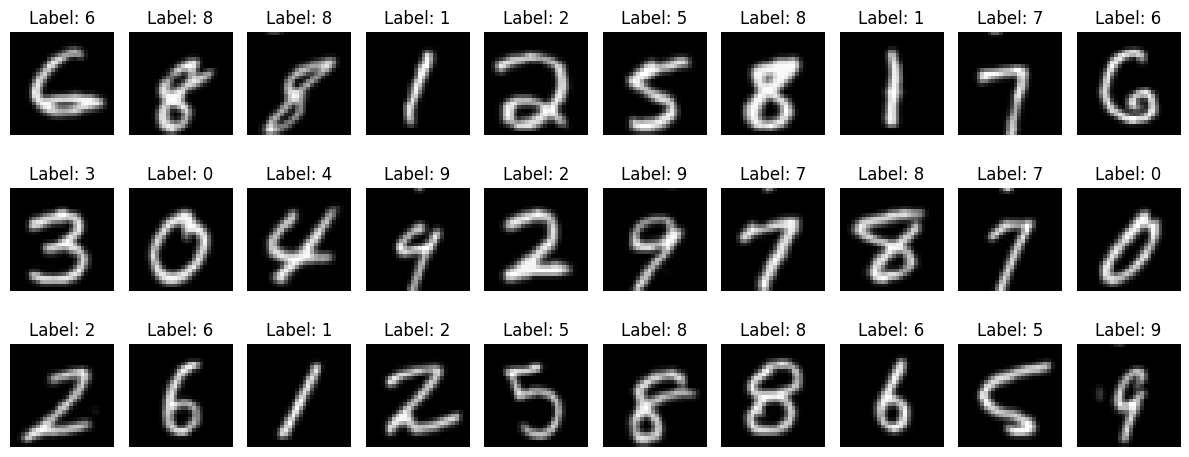

In [60]:
fig, axes = plt.subplots(3, 10, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

Misclassified test samples: 1338


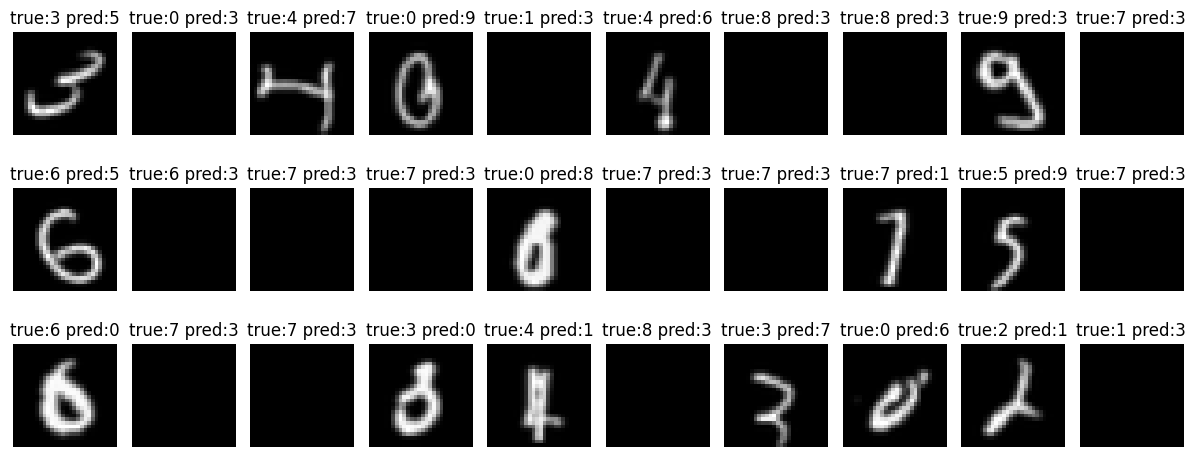

In [61]:
# MISCLASSIFIED

y_pred_test = predict_batch(X_test, layers)
misclassified_idx = np.where(y_pred_test != y_test)[0]

print(f"Misclassified test samples: {len(misclassified_idx)}")

n_plot = min(30, len(misclassified_idx))
fig, axes = plt.subplots(3, 10, figsize=(12, 5))

for ax, idx in zip(axes.flat, misclassified_idx[:n_plot]):
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"true:{y_test[idx]} pred:{y_pred_test[idx]}")
    ax.axis('off')

for ax in axes.flat[n_plot:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

# Part 2